# Loading and Preparing TF-IDF Data

In [4]:
import zipfile
import os

zip_files = ["X_train_tfidf.npz.zip", "X_val_tfidf.npz.zip", "X_test_tfidf.npz.zip"]

for zip_name in zip_files:
    extract_folder = zip_name.replace(".zip", "")
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)

print("Done extracting.")
print(os.listdir())

Done extracting.
['.config', 'X_val_tfidf.npz', 'X_train_tfidf.npz.zip', 'y_test.npy', 'X_test_tfidf.npz.zip', 'y_val.npy', 'X_train_tfidf.npz', 'y_train.npy', 'X_val_tfidf.npz.zip', 'X_test_tfidf.npz', 'sample_data']


In [5]:
import numpy as np
from scipy.sparse import csr_matrix

# Function to load sparse matrix from folder
def load_sparse_from_folder(folder_path):
    data = np.load(f"{folder_path}/data.npy")
    indices = np.load(f"{folder_path}/indices.npy")
    indptr = np.load(f"{folder_path}/indptr.npy")
    shape = tuple(np.load(f"{folder_path}/shape.npy"))
    return csr_matrix((data, indices, indptr), shape=shape)

# Load TF-IDF matrices
X_train = load_sparse_from_folder("X_train_tfidf.npz")
X_val = load_sparse_from_folder("X_val_tfidf.npz")
X_test = load_sparse_from_folder("X_test_tfidf.npz")

# Load labels
y_train = np.load("y_train.npy")
y_val = np.load("y_val.npy")
y_test = np.load("y_test.npy")

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (75000, 20000)
Validation shape: (44767, 20000)
Test shape: (89535, 20000)


# Train Initial Linear SVM Model

In [6]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Initial baseline model
svm_baseline = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

# Train model
svm_baseline.fit(X_train, y_train)

# Predict on validation set
y_val_pred = svm_baseline.predict(X_val)

# Compute validation metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_macro_f1 = f1_score(y_val, y_val_pred, average="macro")
val_weighted_f1 = f1_score(y_val, y_val_pred, average="weighted")
val_precision = precision_score(y_val, y_val_pred, average="weighted", zero_division=0)
val_recall = recall_score(y_val, y_val_pred, average="weighted", zero_division=0)

print("Validation Accuracy:", val_accuracy)
print("Validation Macro F1:", val_macro_f1)
print("Validation Weighted F1:", val_weighted_f1)
print("Validation Precision:", val_precision)
print("Validation Recall:", val_recall)

Validation Accuracy: 0.6907766881854938
Validation Macro F1: 0.587613269747347
Validation Weighted F1: 0.7116919567913385
Validation Precision: 0.7536392238021711
Validation Recall: 0.6907766881854938


# Hyperparameter Tuning for Linear SVM
Since the dataset is imbalanced, Macro F1-score was used to select the best hyperparameter. Macro F1 gives equal importance to all classes, ensuring that minority classes are properly evaluated during model tuning.

In [7]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results = []

C_values = [0.01, 0.1, 1, 10]

for c in C_values:
    model = LinearSVC(
        C=c,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    results.append({
        "Model": "Linear SVM (TF-IDF)",
        "C": c,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Macro F1": f1_score(y_val, y_val_pred, average="macro"),
        "Weighted F1": f1_score(y_val, y_val_pred, average="weighted"),
        "Precision": precision_score(y_val, y_val_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_val, y_val_pred, average="weighted", zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="Macro F1", ascending=False)

,Model,C,Accuracy,Macro F1,Weighted F1,Precision,Recall
1,Linear SVM (TF-IDF),0.10,0.718096,0.599491,0.732214,0.756437,0.718096
2,Linear SVM (TF-IDF),1.00,0.690777,0.587613,0.711692,0.753639,0.690777
3,Linear SVM (TF-IDF),10.00,0.649094,0.557998,0.675842,0.738590,0.649094
0,Linear SVM (TF-IDF),0.01,0.696473,0.548589,0.707076,0.724746,0.696473


# Select the Best Hyperparameter

In [8]:
best_row = results_df.sort_values(by="Macro F1", ascending=False).iloc[0]
best_row

,1
Model,Linear SVM (TF-IDF)
C,0.1
Accuracy,0.718096
Macro F1,0.599491
Weighted F1,0.732214
Precision,0.756437
Recall,0.718096


# Train the Best Model and Evaluate on the Test Set

In [9]:
best_c = best_row["C"]

final_model = LinearSVC(
    C=best_c,
    class_weight="balanced",
    random_state=42
)

final_model.fit(X_train, y_train)
y_test_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")
test_weighted_f1 = f1_score(y_test, y_test_pred, average="weighted")
test_precision = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)

print("Best C:", best_c)
print("Test Accuracy:", test_accuracy)
print("Test Macro F1:", test_macro_f1)
print("Test Weighted F1:", test_weighted_f1)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

Best C: 0.1
Test Accuracy: 0.7179203663371866
Test Macro F1: 0.5989102489721815
Test Weighted F1: 0.7324467345584051
Test Precision: 0.7574502762317806
Test Recall: 0.7179203663371866


# Classification Report and Confusion Matrix

Classification Report:

              precision    recall  f1-score   support

           1       0.66      0.77      0.71      8839
           2       0.42      0.54      0.47      4923
           3       0.46      0.55      0.50      6973
           4       0.41      0.53      0.46     12680
           5       0.92      0.79      0.85     56120

    accuracy                           0.72     89535
   macro avg       0.57      0.64      0.60     89535
weighted avg       0.76      0.72      0.73     89535



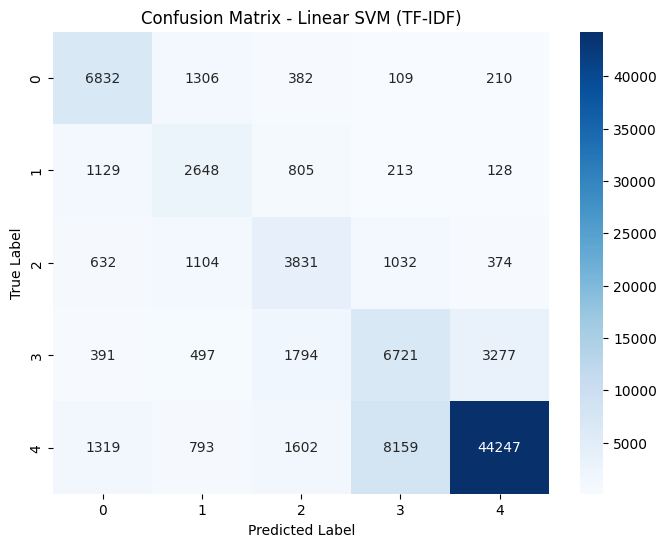

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Classification Report:\n")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Linear SVM (TF-IDF)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The confusion matrix illustrates the performance of the Linear SVM model using TF-IDF features on the test dataset. Each row represents the actual (true) class, while each column represents the predicted class. The diagonal values correspond to correctly classified instances, whereas the off-diagonal values indicate misclassifications.

From the matrix, it can be observed that most predictions are concentrated along the diagonal, indicating that the model correctly classified a large portion of the data. In particular, class 4 has the highest number of correct predictions (44,247), which suggests that the model performs very well in identifying this class. However, some misclassifications occur between neighboring classes, especially between classes 2 and 3, where the model occasionally confuses similar labels.

Overall, the confusion matrix confirms the effectiveness of the Linear SVM model, achieving an overall accuracy of approximately 72%. The model demonstrates strong performance for the dominant classes while showing moderate confusion among certain mid-range classes.

# Save the Final Linear SVM Model

In [11]:
import joblib

joblib.dump(final_model, "lsvm_tfidf_model.pkl")

print("Model saved successfully.")

Model saved successfully.
